# 📈 18 - Series de Tiempo
**Libro:** Estadística aplicada a negocios y economía. 17a Edición

**Autor:** Lind, Marchal, Wathen

---

## 📚 Apuntes
**Autor** : José Reyes.

**Fecha** : 23/07/2026.


---

### 📋 Temas
1. **Componentes de una serie de tiempo**.
2. **Promedio Móvil**.
3. **Promedio Móvil Ponderado**.

---

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Componentes de una serie de tiempo

- Tendencia
- Variación cíclica
- Variación estacional
- Variación irregular

### 1.1 Tendencia secular

Dirección uniforme de una serie de tiempo a largo plazo.

In [2]:
timec_tendencia_secular = pd.DataFrame({
    "Años": [ i for i in range(1996, 2016) ],
    "Asociados": [ 98.1, 124.4, 156.7, 201.4, 227.3, 256.3, 280.9, 298.8, 323.1, 344.8, 364.4, 331.0, 322.0, 317.0, 321.0, 331.0, 340.0, 365.0, 371.0, 385.0]
})

In [3]:
timec_tendencia_secular.head()

,Años,Asociados
0,1996,98.1
1,1997,124.4
2,1998,156.7
3,1999,201.4
4,2000,227.3


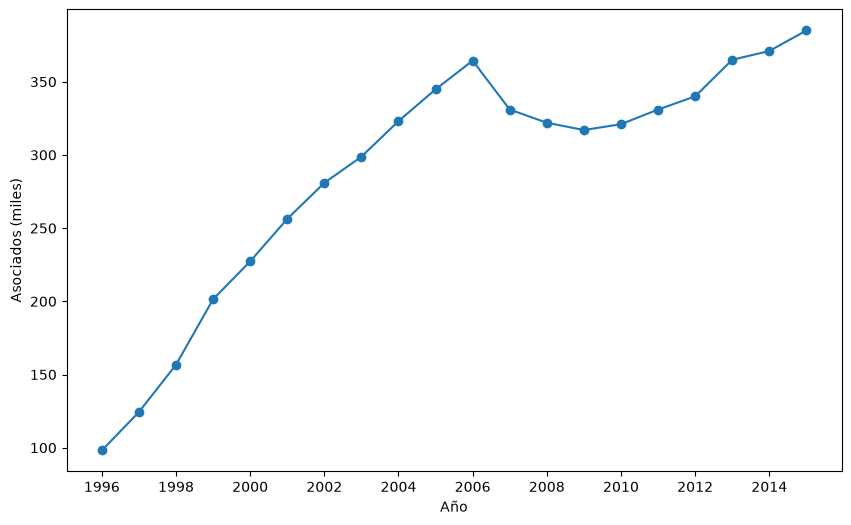

In [4]:
# Visualización de tendencia secular

plt.figure(figsize=(10, 6))
plt.plot(timec_tendencia_secular["Años"], timec_tendencia_secular["Asociados"], marker='o')

plt.xlabel("Año")
plt.ylabel("Asociados (miles)")

plt.xticks(range(1996, 2016, 2))

plt.show()

### 1.2 Variación cíclica

Aumento y reducción de una serie de tiempo durante periodos mayores a un año

In [5]:
venta_baterias_df = pd.DataFrame({
    "Año" : [ i for i in range(1996, 2017) ],
    "Venta Baterías (miles)": [ 24.0, 30.0, 31.0, 26.5, 27.0, 27.5, 34.0, 35.0, 31.0, 32.0, 35.5, 41.0, 42.0, 38.0, 39.0, 46.0, 52.0, 53.5, 47.0, 51.0, 48.0 ]
})

In [6]:
venta_baterias_df.head()

,Año,Venta Baterías (miles)
0,1996,24.0
1,1997,30.0
2,1998,31.0
3,1999,26.5
4,2000,27.0


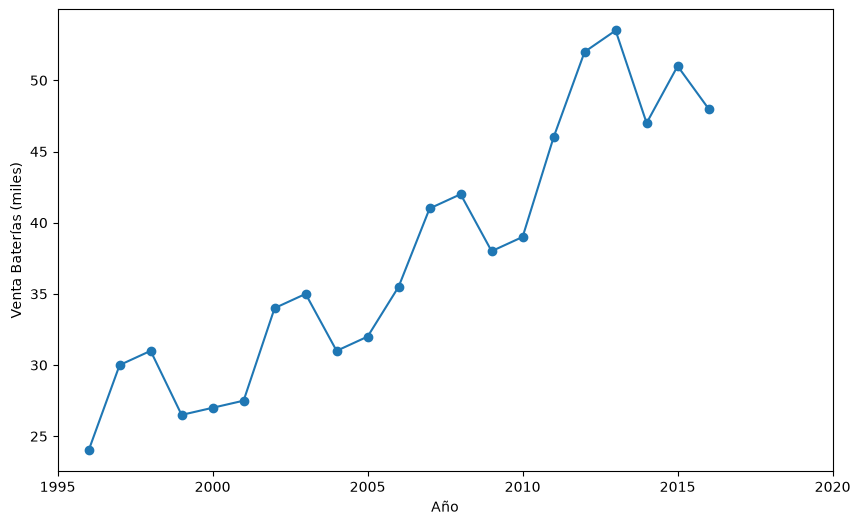

In [7]:
# Visualizando la variación cíclica

plt.figure(figsize=(10, 6))

plt.plot(venta_baterias_df["Año"], venta_baterias_df["Venta Baterías (miles)"], marker='o')

plt.xlabel("Año")
plt.ylabel("Venta Baterías (miles)")

plt.xticks(range(1995, 2021, 5))

plt.show()

### 1.3 Variación estacional

Patrones de cambio en una serie de tiempo en un año; estos tienden a repetirse cada año

In [14]:
ventas_deportes_df = pd.DataFrame({
    "Año": [ 2014, 2014, 2014, 2014,
            2015, 2015, 2015, 2015,
            2016, 2016, 2016, 2016, ],
    "Trimestre": [ 1, 2, 3, 4,
                  5, 6, 7, 8,
                  9, 10, 11, 12],
    "Ventas (millones de dólares)": [ 9.0, 10.2, 3.5, 5.0, 12.0, 14.1, 4.4, 7.3, 16.0, 18.3, 4.6, 8.6 ]
})

In [15]:
ventas_deportes_df.head()

,Año,Trimestre,Ventas (millones de dólares)
0,2014,1,9.0
1,2014,2,10.2
2,2014,3,3.5
3,2014,4,5.0
4,2015,5,12.0


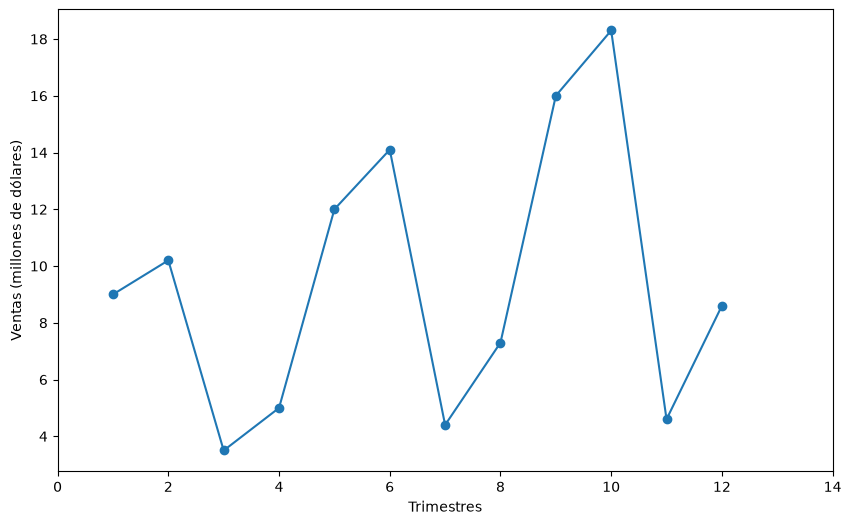

In [26]:
# Visualizando la gráfica

plt.figure(figsize=(10, 6))

plt.plot(ventas_deportes_df["Trimestre"], ventas_deportes_df["Ventas (millones de dólares)"], marker='o')

plt.xlabel("Trimestres")
plt.ylabel("Ventas (millones de dólares)")

plt.xticks(range(0, 15, 2))

plt.show()

### 1.4 Variación irregular

Fluctuaciones episódicas impredecibles, pero posibles de identificar

In [38]:
hospedajes_hotel_df = pd.DataFrame({
    "Año": [ i for i in range(2016, 2023)],
    "Reservaciones (miles)": [ 23.3, 22.8, 20.7, 20.4, 1.8, 2.4, 8.1]
})

In [39]:
hospedajes_hotel_df.head()

,Año,Reservaciones (miles)
0,2016,23.3
1,2017,22.8
2,2018,20.7
3,2019,20.4
4,2020,1.8


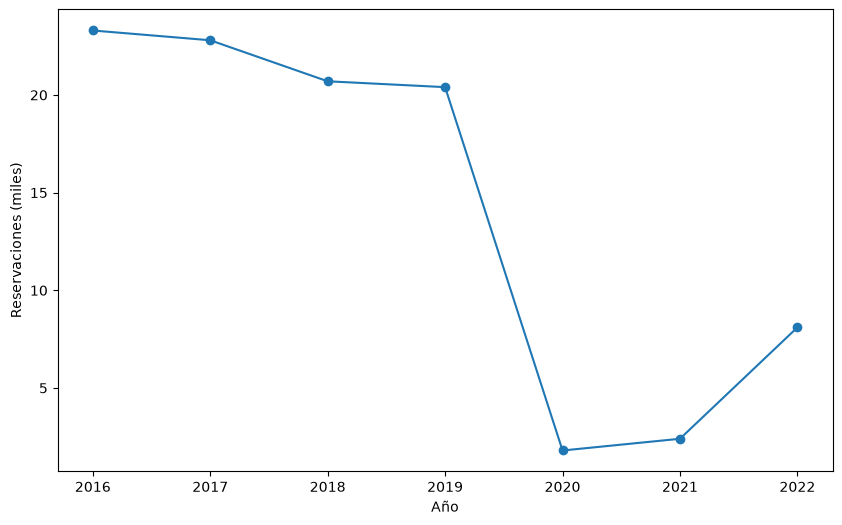

In [40]:
# Visualizando la gráfica

plt.figure(figsize=(10, 6))

plt.plot(hospedajes_hotel_df["Año"], hospedajes_hotel_df["Reservaciones (miles)"], marker='o')

plt.xlabel("Año")
plt.ylabel("Reservaciones (miles)")

plt.xticks(range(2016, 2023))

plt.show()

## 2. Promedio Móvil

Sirve para suavizar una serie de tiempo y apreciar su tendencia.

Solo suaviza las fluctuaciones de los valores desplazando los promedios aritméticos en la serie de tiempo.

### 2.1 Promedio Móvil Centralizado

El valor se asigna al punto medio de la ventana (mediana).

Utiliza tanto información del pasado como del futuro (el registro actual, el anterior y el siguiente). Es ideal para suavizar series históricas estáticas, gráficos o análisis donde ya cuentas con toda la base de datos completa.

In [41]:
ventas_prom_movil = pd.DataFrame({
    "Año": [ i for i in range(1991, 2017)],
    "Ventas (millones de dólares)": [ 1, 2, 3, 4, 5, 4, 3, 2, 3, 4, 5, 6, 5, 4, 3, 4, 5, 6, 7, 6, 5, 4, 5, 6, 7, 8]
})

In [46]:
# Promedio móvil con ventana a 7 años

ventas_prom_movil['Promedio móvil a 7 años'] = ventas_prom_movil["Ventas (millones de dólares)"].rolling(window=7, center=True).mean()

In [48]:
ventas_prom_movil

,Año,Ventas (millones de dólares),Promedio móvil a 7 años
0,1991,1,NaN
1,1992,2,NaN
2,1993,3,NaN
3,1994,4,3.142857
4,1995,5,3.285714
5,1996,4,3.428571
6,1997,3,3.571429
7,1998,2,3.714286
8,1999,3,3.857143
9,2000,4,4.000000


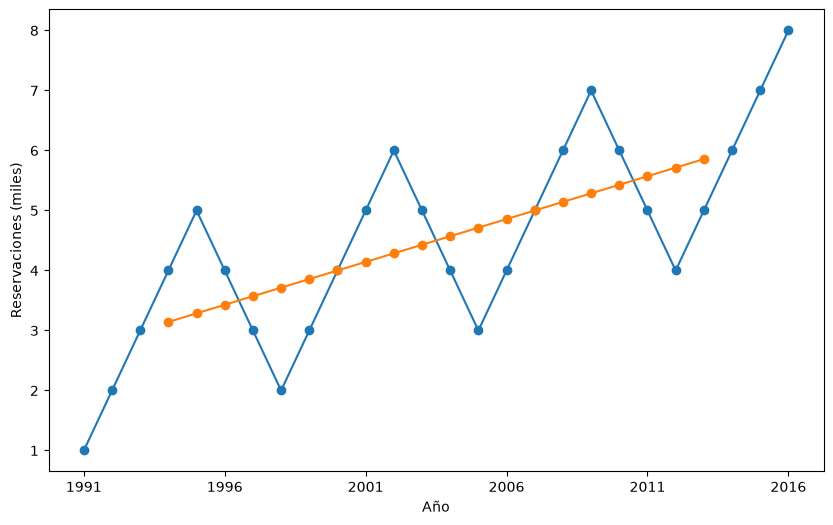

In [52]:
# Visualización

plt.figure(figsize=(10, 6))

plt.plot(ventas_prom_movil["Año"], ventas_prom_movil["Ventas (millones de dólares)"], marker='o')
plt.plot(ventas_prom_movil["Año"], ventas_prom_movil["Promedio móvil a 7 años"], marker='o')


plt.xlabel("Año")
plt.ylabel("Reservaciones (miles)")

plt.xticks(range(1991, 2017, 5))

plt.show()

## 3. Promedio Móvil Ponderado

En un promedio móvil se usa la misma ponderación para cada observación. 

En el promedio móvil ponderado se usa una posible ponderación distinta para cada valor.

La suma de las ponderaciones, dependiendo el valor de cada ventana de tiempo, deben ser igual a 1.

In [59]:
asistencia_eventos_df = pd.DataFrame({
    "Año": [ i for i in range(1996, 2016)],
    "Asistencia (miles)": [ 7445, 7405, 11450, 11224, 11703, 11890, 12380, 12181, 12557, 12700, 19300, 22100, 22720, 21136, 22785, 23377, 23300, 23500, 23300, 24400]
})

In [60]:
# Promedio móvil a tres años
asistencia_eventos_df['Promedio móvil a 3 años'] = asistencia_eventos_df["Asistencia (miles)"].rolling(window=3, center=True).mean()

# Promedio ponderado a 3 años con ponderaciones [0.2, 0.3, 0.5] = 1.0
weights = [0.2, 0.3, 0.5]
asistencia_eventos_df['Promedio ponderado a 3 años'] = asistencia_eventos_df["Asistencia (miles)"].rolling(window=3, center=True).apply(lambda x: np.dot(x, weights), raw=True)

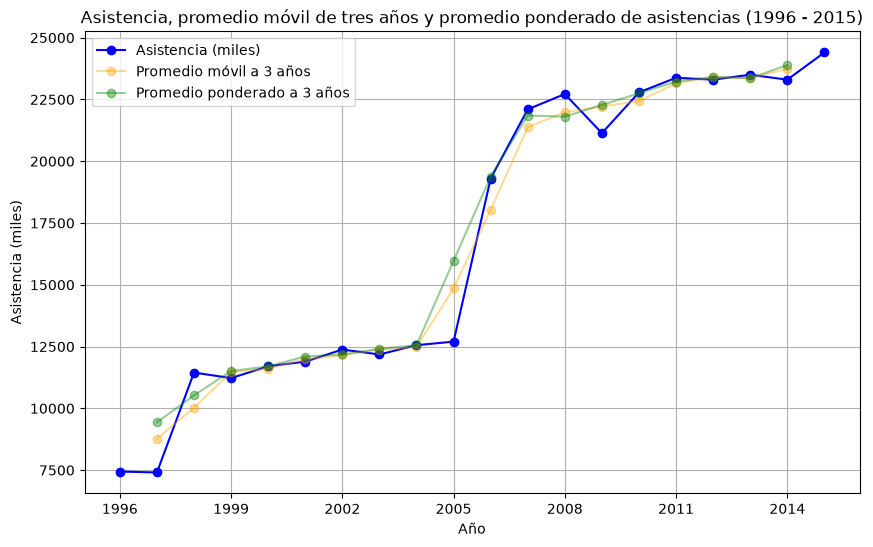

In [73]:
# Visualización

plt.figure(figsize=(10, 6))

plt.plot(asistencia_eventos_df["Año"], asistencia_eventos_df["Asistencia (miles)"], color="blue", marker='o', label="Asistencia (miles)")
plt.plot(asistencia_eventos_df["Año"], asistencia_eventos_df["Promedio móvil a 3 años"], color="orange", marker='o', label="Promedio móvil a 3 años", alpha=0.4)
plt.plot(asistencia_eventos_df["Año"], asistencia_eventos_df["Promedio ponderado a 3 años"], color="green", marker='o', label="Promedio ponderado a 3 años", alpha=0.4)



plt.xlabel("Año")
plt.ylabel("Asistencia (miles)")

plt.xticks(range(1996, 2015, 3))
plt.legend()

plt.title("Asistencia, promedio móvil de tres años y promedio ponderado de asistencias (1996 - 2015)")
plt.grid(True)


plt.show()